In [70]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


# Modelo Guassian NB

In [71]:
datos = load_breast_cancer()

In [72]:
X = datos.data
y = datos.target

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 24)

In [74]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [75]:
print("Accuracy del Guassian NB",
    accuracy_score(
    y_test,
    y_pred)
)

Accuracy del Guassian NB 0.9210526315789473


In [76]:
score = f1_score(y_test, y_pred)
print("F1 score: ", score)

F1 score:  0.9379310344827586


In [77]:
precision = precision_score(y_test, y_pred)
print("Precision score: ", precision)

Precision score:  0.9444444444444444


In [78]:
recall = recall_score(y_test, y_pred)
print("Recall: ", recall)

Recall:  0.9315068493150684


In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89        41
           1       0.94      0.93      0.94        73

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.91       114
weighted avg       0.92      0.92      0.92       114



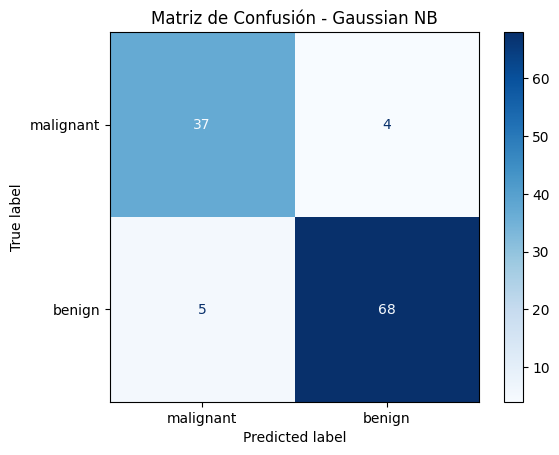

In [80]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=datos.target_names)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Gaussian NB")
plt.show()

El modelo Gaussian Naive Bayes alcanzó una exactitud del 92%, lo que significa que clasificó correctamente 92 de cada 100 observaciones. La precisión para la clase 0 fue de 88% y para la clase 1 fue de 94%, indicando que las predicciones realizadas por el modelo son bastante confiables. El recall fue de 90% para la clase 0 y 93% para la clase 1, demostrando que el modelo logró identificar correctamente la mayoría de los casos reales de ambas clases. El F1-Score fue de 89% para la clase 0 y 94% para la clase 1, reflejando un equilibrio adecuado entre precisión y recall. En general, el modelo presenta un desempeño sólido y una buena capacidad de clasificación para el conjunto de datos de cáncer de mama.

# Modelo Multinomial NB

In [81]:
categorias = [
    'sci.space',
    'rec.sport.baseball'
]

In [82]:
datos = fetch_20newsgroups(subset='train', categories=categorias)

In [83]:
vectorizador = CountVectorizer()

In [84]:
Xm = vectorizador.fit_transform(datos.data)
ym = datos.target

In [85]:
X_trainM, X_testM, y_trainM, y_testM = train_test_split(Xm, ym, test_size= 0.3, random_state=24)

In [86]:
modeloM = MultinomialNB()
modeloM.fit(X_trainM, y_trainM)
y_predM = modeloM.predict(X_testM)

In [87]:
print("Modelo Multinomial: ",
    accuracy_score
     (y_true = y_testM, y_pred = y_predM))

Modelo Multinomial:  0.9971988795518207


In [88]:
score = f1_score(y_testM, y_predM)
print("F1 score: ", score)

F1 score:  0.9970501474926253


In [89]:
precision = precision_score(y_testM, y_predM)
print("Precision score: ", precision)

Precision score:  1.0


In [90]:
recall = recall_score(y_testM, y_predM)
print("Recall: ", recall)

Recall:  0.9941176470588236


In [91]:
print(classification_report(y_testM, y_predM))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       187
           1       1.00      0.99      1.00       170

    accuracy                           1.00       357
   macro avg       1.00      1.00      1.00       357
weighted avg       1.00      1.00      1.00       357



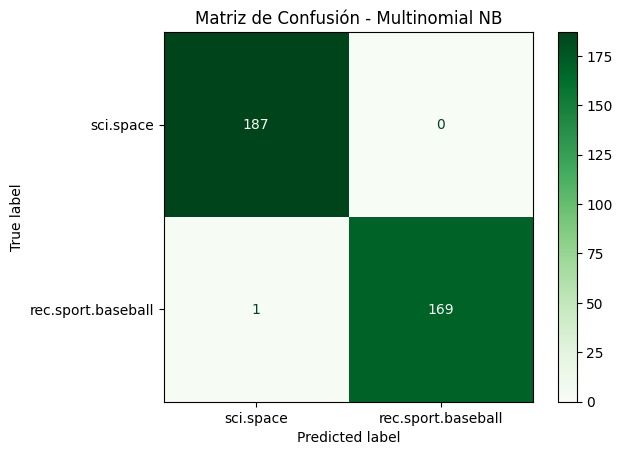

In [92]:
cm = confusion_matrix(y_testM, y_predM)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categorias)
disp.plot(cmap='Greens')
plt.title("Matriz de Confusión - Multinomial NB")
plt.show()

El modelo Multinomial Naive Bayes obtuvo un accuracy cercano al 100%, mostrando un rendimiento excepcional en la clasificación de documentos de texto. La precisión alcanzó valores de 99% para la clase 0 y 100% para la clase 1, mientras que el recall fue de 100% y 99% respectivamente. Los valores de F1-Score también fueron prácticamente perfectos, alcanzando 100% en ambas clases. Estos resultados indican que el modelo fue capaz de distinguir casi sin errores entre las categorías analizadas. La matriz de confusión debería mostrar muy pocos errores de clasificación, confirmando la alta efectividad de este algoritmo para problemas de clasificación textual basados en frecuencias de palabras.

# Modelo Bernoulli NB

In [93]:
modeloB = BernoulliNB()
modeloB.fit(X_trainM, y_trainM)
y_predB = modeloB.predict(X_testM)

In [94]:
print("Modelo Bernoulli NB",
accuracy_score(y_true = y_testM, y_pred = y_predB))

Modelo Bernoulli NB 0.9159663865546218


In [95]:
score = f1_score(y_testM, y_predB)
print("F1 score: ", score)

F1 score:  0.9038461538461539


In [96]:
precision = precision_score(y_testM, y_predB)
print("Precision score: ", precision)

Precision score:  0.9929577464788732


In [97]:
recall = recall_score(y_testM, y_predB)
print("Recall: ", recall)

Recall:  0.8294117647058824


In [98]:
print(classification_report(y_testM, y_predB))

              precision    recall  f1-score   support

           0       0.87      0.99      0.93       187
           1       0.99      0.83      0.90       170

    accuracy                           0.92       357
   macro avg       0.93      0.91      0.91       357
weighted avg       0.93      0.92      0.92       357



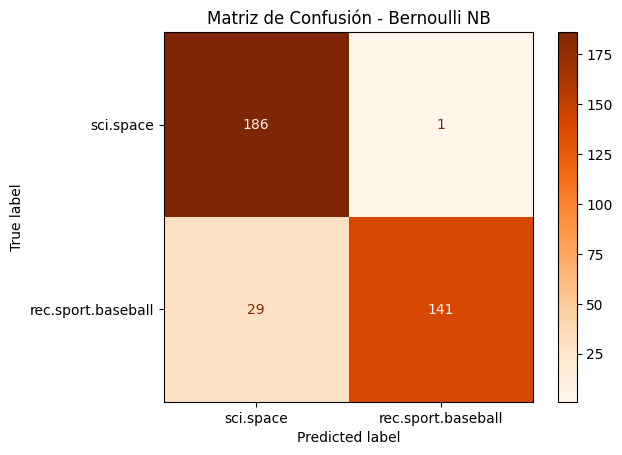

In [99]:
cm = confusion_matrix(y_testM, y_predB)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categorias)
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusión - Bernoulli NB")
plt.show()

El modelo Bernoulli Naive Bayes alcanzó una exactitud del 92%, mostrando un desempeño bueno pero inferior al de Multinomial Naive Bayes. Para la clase 0 obtuvo una precisión de 87% y un recall de 99%, lo que significa que detectó casi todos los casos reales de esa clase. Para la clase 1 la precisión fue de 99%, pero el recall descendió a 83%, indicando que algunos elementos de esta categoría fueron clasificados incorrectamente. Los valores de F1-Score fueron de 93% para la clase 0 y 90% para la clase 1, reflejando un rendimiento equilibrado aunque con ciertas dificultades para recuperar todos los ejemplos de la clase 1. En términos generales, el modelo presenta buenos resultados, pero no alcanza la precisión casi perfecta obtenida por Multinomial Naive Bayes.